In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("Pokemon.csv")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


**Basic Info**

In [24]:
print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

BASIC INFO
Shape: (800, 13)

Columns: ['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']

Data Types:
#             int64
Name            str
Type 1          str
Type 2          str
Total         int64
HP            int64
Attack        int64
Defense       int64
Sp. Atk       int64
Sp. Def       int64
Speed         int64
Generation    int64
Legendary      bool
dtype: object

Missing Values:
#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Duplicate Rows: 0


**Descriptive Statistics**

In [25]:
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
numeric_cols = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
print(df[numeric_cols].describe().round(2))

DESCRIPTIVE STATISTICS
        Total      HP  Attack  Defense  Sp. Atk  Sp. Def   Speed
count  800.00  800.00  800.00   800.00   800.00   800.00  800.00
mean   435.10   69.26   79.00    73.84    72.82    71.90   68.28
std    119.96   25.53   32.46    31.18    32.72    27.83   29.06
min    180.00    1.00    5.00     5.00    10.00    20.00    5.00
25%    330.00   50.00   55.00    50.00    49.75    50.00   45.00
50%    450.00   65.00   75.00    70.00    65.00    70.00   65.00
75%    515.00   80.00  100.00    90.00    95.00    90.00   90.00
max    780.00  255.00  190.00   230.00   194.00   230.00  180.00


**Categorical Summary**

In [26]:
print("\n" + "=" * 50)
print("CATEGORICAL SUMMARIES")
print("=" * 50)
print(f"\nType 1 Distribution:\n{df['Type 1'].value_counts()}")
print(f"\nGeneration Distribution:\n{df['Generation'].value_counts().sort_index()}")
print(f"\nLegendary Count:\n{df['Legendary'].value_counts()}")


CATEGORICAL SUMMARIES

Type 1 Distribution:
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64

Generation Distribution:
Generation
1    166
2    106
3    160
4    121
5    165
6     82
Name: count, dtype: int64

Legendary Count:
Legendary
False    735
True      65
Name: count, dtype: int64


**Group wise analysis**

In [27]:
print("\n" + "=" * 50)
print("MEAN STATS BY TYPE")
print("=" * 50)
print(df.groupby('Type 1')[numeric_cols].mean().round(1).sort_values('Total', ascending=False))
 
print("\n" + "=" * 50)
print("LEGENDARY vs NON-LEGENDARY")
print("=" * 50)
print(df.groupby('Legendary')[numeric_cols].mean().round(1))


MEAN STATS BY TYPE
          Total    HP  Attack  Defense  Sp. Atk  Sp. Def  Speed
Type 1                                                         
Dragon    550.5  83.3   112.1     86.4     96.8     88.8   83.0
Steel     487.7  65.2    92.7    126.4     67.5     80.6   55.3
Flying    485.0  70.8    78.8     66.2     94.2     72.5  102.5
Psychic   475.9  70.6    71.5     67.7     98.4     86.3   81.5
Fire      458.1  69.9    84.8     67.8     89.0     72.2   74.4
Rock      453.8  65.4    92.9    100.8     63.3     75.5   55.9
Dark      445.7  66.8    88.4     70.2     74.6     69.5   76.2
Electric  443.4  59.8    69.1     66.3     90.0     73.7   84.5
Ghost     439.6  64.4    73.8     81.2     79.3     76.5   64.3
Ground    437.5  73.8    95.8     84.8     56.5     62.8   63.9
Ice       433.5  72.0    72.8     71.4     77.5     76.3   63.5
Water     430.5  72.1    74.2     72.9     74.8     70.5   66.0
Grass     421.1  67.3    73.2     70.8     77.5     70.4   61.9
Fighting  416.4  69.

**Top 10 Pokemon by Total Stats**

In [28]:
print("\n" + "=" * 50)
print("TOP 10 POKEMON BY TOTAL STATS")
print("=" * 50)
print(df[['Name', 'Type 1', 'Total', 'Legendary']].sort_values('Total', ascending=False).head(10).to_string(index=False))


TOP 10 POKEMON BY TOTAL STATS
                   Name  Type 1  Total  Legendary
  RayquazaMega Rayquaza  Dragon    780       True
    MewtwoMega Mewtwo X Psychic    780       True
    MewtwoMega Mewtwo Y Psychic    780       True
    KyogrePrimal Kyogre   Water    770       True
  GroudonPrimal Groudon  Ground    770       True
                 Arceus  Normal    720       True
      LatiasMega Latias  Dragon    700       True
  GarchompMega Garchomp  Dragon    700      False
MetagrossMega Metagross   Steel    700      False
    DiancieMega Diancie    Rock    700       True


**Pokemon Count by Type**

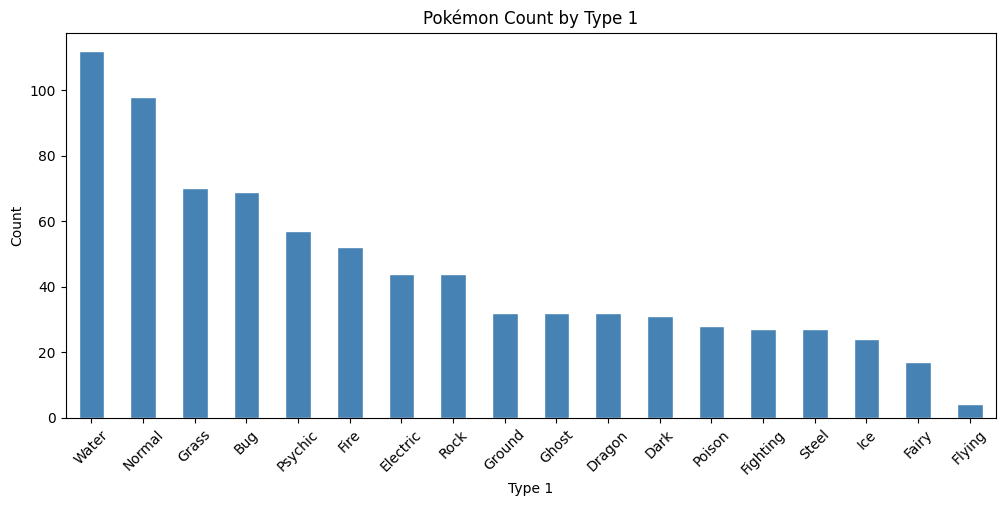

In [33]:
plt.figure(figsize=(12, 5))
df['Type 1'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Pokémon Count by Type 1")
plt.xlabel("Type 1")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Generation Distribution**

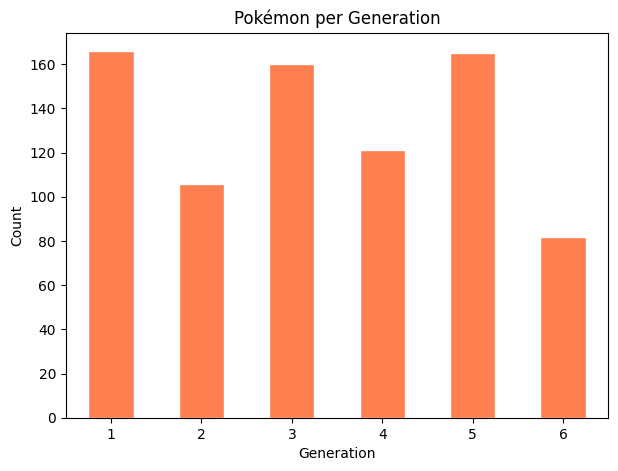

In [34]:
plt.figure(figsize=(7, 5))
df['Generation'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='white')
plt.title("Pokémon per Generation")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Legendary vs Non-Legendary Pokemon**

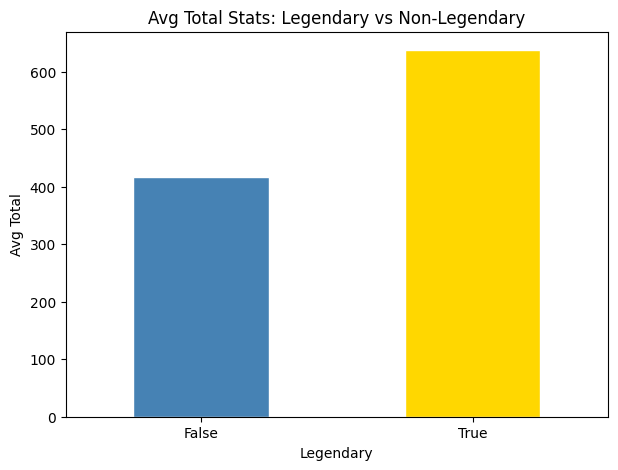

In [36]:
plt.figure(figsize=(7, 5))
df.groupby('Legendary')['Total'].mean().plot(
    kind='bar', color=['steelblue', 'gold'], edgecolor='white'
)
plt.title("Avg Total Stats: Legendary vs Non-Legendary")
plt.xlabel("Legendary")
plt.ylabel("Avg Total")
plt.xticks(rotation=0)
plt.show()

**Attack vs Defense**

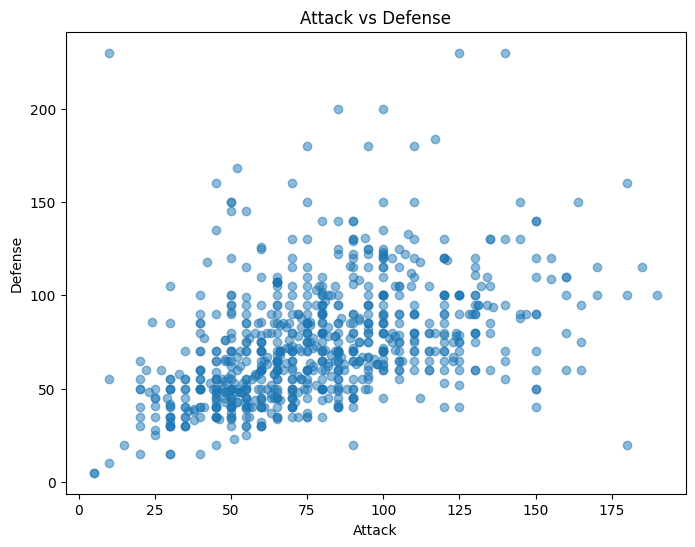

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Attack'], df['Defense'], alpha=0.5)
plt.title("Attack vs Defense")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.show()